In [43]:

from google.colab import drive
drive.mount('/content/drive')
base = "/content/drive/MyDrive/AI/"


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [44]:
#PROBLEM1

#STEP1

import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/AI/bank.csv")
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [45]:
#STEP2
#a
df.info()

objectColumns = df.select_dtypes(include='object').columns
objectColumns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome', 'y'],
      dtype='object')

In [46]:
#b
for col in objectColumns:
  print(f"Column: {col}")
  print(df[col].unique())

Column: job
['management' 'technician' 'entrepreneur' 'blue-collar' 'unknown'
 'retired' 'admin.' 'services' 'self-employed' 'unemployed' 'housemaid'
 'student']
Column: marital
['married' 'single' 'divorced']
Column: education
['tertiary' 'secondary' 'unknown' 'primary']
Column: default
['no' 'yes']
Column: housing
['yes' 'no']
Column: loan
['no' 'yes']
Column: contact
['unknown' 'cellular' 'telephone']
Column: month
['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'jan' 'feb' 'mar' 'apr' 'sep']
Column: poutcome
['unknown' 'failure' 'other' 'success']
Column: y
['no' 'yes']


In [47]:
#c
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [48]:
#STEP3
dfNum = df.drop(columns=objectColumns)

dfNum.to_csv("/content/drive/MyDrive/AI/banknumericdata.csv",index = False)

dfNum.head()

,age,balance,day,duration,campaign,pdays,previous
0,58,2143,5,261,1,-1,0
1,44,29,5,151,1,-1,0
2,33,2,5,76,1,-1,0
3,47,1506,5,92,1,-1,0
4,33,1,5,198,1,-1,0


In [50]:
#STEP4
bankNumb = pd.read_csv("/content/drive/MyDrive/AI/banknumericdata.csv")

bankNumb.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [53]:
#PROBLEM2
#STEP1
dfMed = pd.read_csv("/content/drive/MyDrive/AI/medical_students_dataset.csv")
dfMed.head();l

,Student ID,Age,Gender,Height,Weight,Blood Type,BMI,Temperature,Heart Rate,Blood Pressure,Cholesterol,Diabetes,Smoking
0,1.0,18.0,Female,161.777924,72.354947,O,27.645835,NaN,95.0,109.0,203.0,No,NaN
1,2.0,NaN,Male,152.069157,47.630941,B,NaN,98.714977,93.0,104.0,163.0,No,No
2,3.0,32.0,Female,182.537664,55.741083,A,16.729017,98.260293,76.0,130.0,216.0,Yes,No
3,NaN,30.0,Male,182.112867,63.332207,B,19.096042,98.839605,99.0,112.0,141.0,No,Yes
4,5.0,23.0,Female,NaN,46.234173,O,NaN,98.480008,95.0,NaN,231.0,No,No


In [74]:
#STEP2
dfMed.info()
dfMed.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 187121 entries, 0 to 199999
Data columns (total 13 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Student ID      167285 non-null  float64
 1   Age             187121 non-null  float64
 2   Gender          187121 non-null  object 
 3   Height          187121 non-null  float64
 4   Weight          187121 non-null  float64
 5   Blood Type      187121 non-null  object 
 6   BMI             187121 non-null  float64
 7   Temperature     187121 non-null  float64
 8   Heart Rate      187121 non-null  float64
 9   Blood Pressure  187121 non-null  float64
 10  Cholesterol     187121 non-null  float64
 11  Diabetes        187121 non-null  object 
 12  Smoking         187121 non-null  object 
dtypes: float64(9), object(4)
memory usage: 20.0+ MB


,0
Student ID,19836
Age,0
Gender,0
Height,0
Weight,0
Blood Type,0
BMI,0
Temperature,0
Heart Rate,0
Blood Pressure,0


In [62]:
#STEP3
numCols = ['Age','Height','Weight','BMI','Temperature','Heart Rate','Blood Pressure','Cholesterol']
dfMed[numCols] = dfMed[numCols].fillna(dfMed[numCols].median())

catCols = ["Gender", "Blood Type", "Diabetes", "Smoking"]
for col in catCols:
    dfMed[col] = dfMed[col].fillna(dfMed[col].mode()[0])

print("Filling up missing values:")
print(dfMed.isnull().sum())


Filling up missing values:
Student ID        19836
Age                   0
Gender                0
Height                0
Weight                0
Blood Type            0
BMI                   0
Temperature           0
Heart Rate            0
Blood Pressure        0
Cholesterol           0
Diabetes              0
Smoking               0
dtype: int64


In [67]:
#STEP4
dfMed= dfMed.drop_duplicates()
print(dfMed.duplicated().sum())

0


In [64]:
#3.2 Titanic
#Problem1
dfTitanic= pd.read_csv("/content/drive/MyDrive/AI/Titanic-Dataset.csv")

selection = ["Name","Pclass","Sex","Age","Fare","Survived"]
dfTpc1 = dfTitanic[selection]

dfTFirstClass = dfTpc1[dfTpc1["Pclass"] ==1]

meanFare = dfTFirstClass["Fare"].mean()
medianFare = dfTFirstClass["Fare"].median()
maxFare = dfTFirstClass["Fare"].max()
minFare = dfTFirstClass["Fare"].min()

print("Fare stats for FirstClass Passengers: ")
print(f"Mean fare: {meanFare}")
print(f"Median fare: {medianFare}")
print(f"Max fare: {maxFare}")
print(f"Min fare: {minFare}")



Fare stats for FirstClass Passengers: 
Mean fare: 84.1546875
Median fare: 60.287499999999994
Max fare: 512.3292
Min fare: 0.0


In [30]:
#Problem2
null_age = dfTpc1["Age"].isnull().sum()
print(f"Number of null values in age: {null_age}")

new_age = dfTpc1.dropna(subset =["Age"])

print("Before", len(dfTpc1))
print("After", len(new_age))

Number of null values in age: 177
Before 891
After 714


In [70]:
#Problem3
titanic2 = dfTitanic.copy()

embark = pd.get_dummies(titanic2["Embarked"], prefix="Embarked")

embark = embark.astype(int)

titanic2 = pd.concat([titanic2, embark], axis=1)

titanic2 = titanic2.drop(columns =["Embarked"])

titanic2.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,0,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,1,0,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,0,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,0,0,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,0,0,1


Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


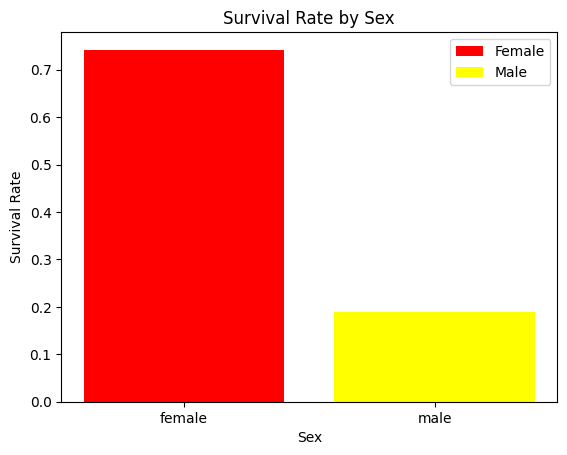

In [73]:
# Problem 4
import matplotlib.pyplot as plt

survival_by_sex = dfTitanic.groupby("Sex")["Survived"].mean()
print(survival_by_sex)

plt.bar(survival_by_sex.index, survival_by_sex.values,
        color=["red", "yellow"],
        label=["Female", "Male"])

plt.xlabel("Sex")
plt.ylabel("Survival Rate")
plt.title("Survival Rate by Sex")

plt.legend()

plt.show()


Embarked         C         Q         S
Sex                                   
female    0.876712  0.750000  0.689655
male      0.305263  0.073171  0.174603


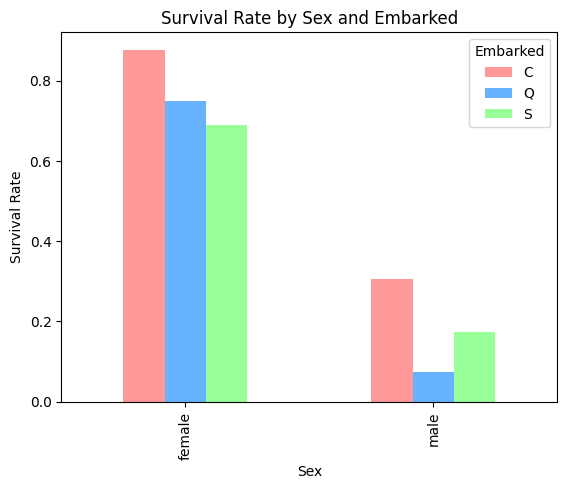

In [72]:
survival_sex_embark = dfTitanic.groupby(["Sex", "Embarked"])["Survived"].mean()

survival_sex_embark = survival_sex_embark.unstack()
print(survival_sex_embark)

survival_sex_embark.plot(
    kind="bar",
    color=["#FF9999", "#66B2FF", "#99FF99"]
)

plt.ylabel("Survival Rate")
plt.title("Survival Rate by Sex and Embarked")

plt.show()
